<a href="https://colab.research.google.com/github/khalidkhankakar/Neural-Networks-from-zero-to-hero/blob/main/deep_learning_book_1/classification_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
print('Chapter # 4 Classification & Regression')

Chapter # 4 Classification & Regression


In [17]:
from keras.datasets import imdb
(train_data, train_labels), (test_data , test_labels) = imdb.load_data(num_words=10_000)

In [18]:
# {34701: 'fawn', ....}
word_idx = imdb.get_word_index()

# Reverse: {'fawn':34701, ....}
# reverse_word_idx[train_data[0][7]]
reverse_word_idx = dict([(value, key) for (key, value) in word_idx.items()])

decode_review = " ".join(
    [reverse_word_idx.get(i-3, "?") for i in train_data[0]]
)

decode_review

"? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for ? and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also ? to the two little boy's that played the ? of norman and paul they were just brilliant children are often left out of the ? list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be praised for what they have done don't you th

## Prepare the Data

In [19]:
import numpy as np

def multi_hot_encode(sequences, num_classes):
  results = np.zeros((len(sequences), num_classes))
  for i, sequence in enumerate(sequences):
    results[i][sequence] = 1.0
  return results

X_train = multi_hot_encode(train_data, 10_000)
X_test = multi_hot_encode(test_data, 10_000)

In [20]:
print('--- Small Example of multi_hot_encode ---')
small_sequence = [1, 3, 0] # A short sequence of word indices
small_num_classes = 5 # A small vocabulary size

small_encoded = multi_hot_encode([small_sequence], small_num_classes)
display(small_encoded)

--- Small Example of multi_hot_encode ---


array([[1., 1., 0., 1., 0.]])

In [21]:
X_train[0]

array([0., 1., 1., ..., 0., 0., 0.])

In [22]:
y_train= train_labels.astype('float32')
y_test= test_labels.astype('float32')

In [32]:
import keras
from keras import layers

model = keras.Sequential([
    layers.Dense(16, activation='relu', input_shape=(10_000,)), # relu(dot((input, w)) + b)
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

In [33]:
# binary_crossentropy is best choice when you dealing with output probabilities
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [34]:
# setting aside you development set
train_x_val = X_train[10_000:]
train_y_val = y_train[10_000:]

dev_x_val = X_train[:10_000]
dev_y_val = y_train[:10_000]

In [35]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=512,
    validation_split=0.2
)

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.7988 - loss: 0.5184 - val_accuracy: 0.8742 - val_loss: 0.3579
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.9071 - loss: 0.2703 - val_accuracy: 0.8904 - val_loss: 0.2807
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9344 - loss: 0.1924 - val_accuracy: 0.8884 - val_loss: 0.2859
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.9488 - loss: 0.1516 - val_accuracy: 0.8916 - val_loss: 0.2861
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.9599 - loss: 0.1232 - val_accuracy: 0.8846 - val_loss: 0.3080
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.9686 - loss: 0.1005 - val_accuracy: 0.8832 - val_loss: 0.3360
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.9762 - loss: 0.0814 - val_accuracy: 0.8800 - val_loss: 0.3608
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.9822 - loss: 0.0677 - val_accuracy: 0.8780 - v

In [36]:
history_dic = history.history
history_dic.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

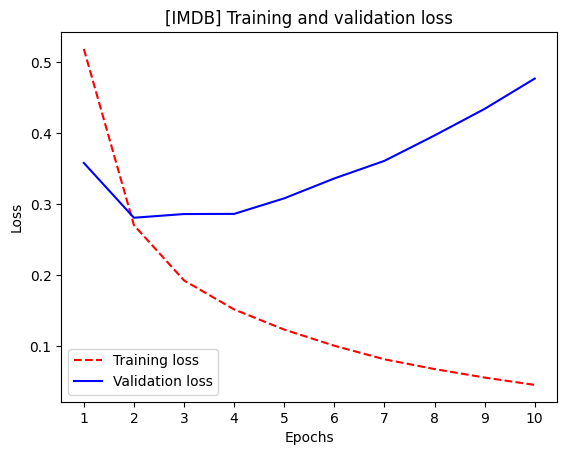

In [37]:
import matplotlib.pyplot as plt
history_dict = history.history
loss_values = history_dict["loss"]
val_loss_values = history_dict["val_loss"]
epochs = range(1, len(loss_values) + 1)
plt.plot(epochs, loss_values, "r--", label="Training loss")
plt.plot(epochs, val_loss_values, "b", label="Validation loss")
plt.title("[IMDB] Training and validation loss")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Loss")
plt.legend()
plt.show()

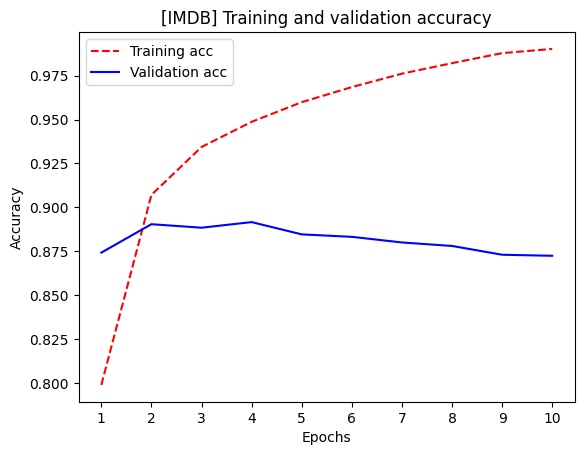

In [38]:
plt.clf()
acc = history_dict["accuracy"]
val_acc = history_dict["val_accuracy"]
plt.plot(epochs, acc, "r--", label="Training acc")
plt.plot(epochs, val_acc, "b", label="Validation acc")
plt.title("[IMDB] Training and validation accuracy")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [39]:
model.predict(X_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([[0.08033385],
       [0.9999927 ],
       [0.01305396],
       ...,
       [0.01748959],
       [0.01518503],
       [0.39437476]], dtype=float32)